# PB-16 — Evaluación de Valor de Negocio

## Objetivo

Evaluar el valor económico del modelo final del Sprint 4 para el caso de telemarketing bancario.

## Pregunta de negocio

¿Cuánto valor genera priorizar llamadas usando el modelo final frente a una estrategia no segmentada?

## Entregables

1. Matriz costo–beneficio.
2. Umbral óptimo de decisión.
3. Gain curve.
4. Lift curve.
5. Impacto económico mensual y anual.
6. Escenarios de sensibilidad
7. Recomendación de negocio para Sprint 6.

### Importar librerías

In [28]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

sys.path.append(os.path.abspath(".."))

from src.evaluation import (
    business_value_at_threshold,
    find_optimal_threshold,
    gain_curve_data,
    lift_curve_data,
    estimate_annual_impact,
    technical_metrics_at_threshold
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### Definir rutas

In [29]:
PROJECT_ROOT = Path("..").resolve()

MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(exist_ok=True)

print("MODELS_DIR:", MODELS_DIR)
print("DATA_DIR:", DATA_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

MODELS_DIR: C:\Users\eduar\OneDrive\Desktop\Telemarketing\dp261-g6\models
DATA_DIR: C:\Users\eduar\OneDrive\Desktop\Telemarketing\dp261-g6\data
REPORTS_DIR: C:\Users\eduar\OneDrive\Desktop\Telemarketing\dp261-g6\reports


### Cargar modelo final y test set

In [30]:
model_path = MODELS_DIR / "final_model.pkl"
test_path = DATA_DIR / "processed" / "test_original.csv"

print("Existe modelo final:", model_path.exists())
print("Existe test_original:", test_path.exists())

model = joblib.load(model_path)

test_df = pd.read_csv(test_path)

X_test = test_df.drop("y", axis=1)
y_test = test_df["y"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print(y_test.value_counts())

Existe modelo final: True
Existe test_original: True
X_test: (8234, 44)
y_test: (8234,)
y
0    7307
1     927
Name: count, dtype: int64


### Obtener probabilidades

In [31]:
if not hasattr(model, "predict_proba"):
    raise ValueError("El modelo final no tiene predict_proba. Se requiere para análisis de umbral.")

y_proba = model.predict_proba(X_test)[:, 1]

y_pred_05 = (y_proba >= 0.5).astype(int)

metrics_05 = technical_metrics_at_threshold(
    y_true=y_test,
    y_proba=y_proba,
    threshold=0.5
)

metrics_05

{'threshold': 0.5,
 'precision': 0.4924318869828456,
 'recall': 0.5264293419633226,
 'f1': 0.5088633993743483,
 'roc_auc': 0.7982916442081148}

## 1. Matriz costo–beneficio

Para traducir el modelo a valor de negocio se definen los siguientes supuestos:

- **True Positive (TP):** cliente interesado correctamente priorizado.
- **False Positive (FP):** cliente no interesado contactado innecesariamente.
- **False Negative (FN):** cliente interesado que no fue priorizado.
- **True Negative (TN):** cliente no interesado correctamente no priorizado.

Los valores económicos deben ser validados con el sponsor del proyecto.

### Supuestos del Negocio

Para evitar una estimación sobredimensionada, los valores de la matriz costo–beneficio se ajustaron al contexto de una campaña bancaria de telemarketing en Perú.

No se considera el monto completo del depósito como ganancia del banco. En su lugar, se estima un beneficio neto por cliente captado, asociado al margen financiero, permanencia del depósito y valor comercial del cliente.

Los supuestos usados son:

| Evento | Descripción | Valor estimado |
|---|---|---:|
| True Positive (TP) | Cliente interesado correctamente priorizado y contactado | S/ 60 |
| False Positive (FP) | Cliente no interesado contactado innecesariamente | -S/ 2.50 |
| False Negative (FN) | Cliente interesado no priorizado | -S/ 40 |
| True Negative (TN) | Cliente no interesado correctamente no contactado | S/ 0 |

El costo de un falso positivo se estima considerando el costo operativo de una llamada de telemarketing en Perú: tiempo del operador, plataforma, supervisión y telefonía. El beneficio por True Positive se define como una utilidad neta conservadora por captación efectiva, no como el monto total depositado.

Estos valores deben validarse posteriormente con el sponsor del banco, especialmente con información real de costo por llamada, ticket promedio de depósito y margen financiero esperado.

In [32]:
benefit_tp = 60      # S/ beneficio neto estimado por cliente interesado correctamente priorizado
cost_fp = -2.5       # S/ costo operativo aproximado por llamada improductiva
cost_fn = -40        # S/ costo de oportunidad por no contactar a un cliente interesado
benefit_tn = 0       # S/ caso neutral

business_assumptions = {
    "benefit_tp_soles": benefit_tp,
    "cost_fp_soles": cost_fp,
    "cost_fn_soles": cost_fn,
    "benefit_tn_soles": benefit_tn
}

business_assumptions

{'benefit_tp_soles': 60,
 'cost_fp_soles': -2.5,
 'cost_fn_soles': -40,
 'benefit_tn_soles': 0}

### Valor con umbral 0.50

In [33]:
value_05 = business_value_at_threshold(
    y_true=y_test,
    y_proba=y_proba,
    threshold=0.5,
    benefit_tp=benefit_tp,
    cost_fp=cost_fp,
    cost_fn=cost_fn,
    benefit_tn=benefit_tn
)

value_05

{'threshold': 0.5,
 'tn': np.int64(6804),
 'fp': np.int64(503),
 'fn': np.int64(439),
 'tp': np.int64(488),
 'valor_total': np.float64(10462.5),
 'valor_por_cliente': np.float64(1.2706461015302404),
 'precision': 0.4924318869828456,
 'recall': 0.5264293419633226,
 'f1': 0.5088633993743483}

## 2. Umbral óptimo de Decisión

### Búsqueda del umbral óptimo

El umbral de 0.50 no necesariamente maximiza el valor de negocio. 
Por ello, se evalúan múltiples umbrales y se selecciona aquel que maximiza el valor económico esperado.

### Celda de cálculo

In [34]:
df_thresholds, best_threshold_row = find_optimal_threshold(
    y_true=y_test,
    y_proba=y_proba,
    benefit_tp=benefit_tp,
    cost_fp=cost_fp,
    cost_fn=cost_fn,
    benefit_tn=benefit_tn
)

print("Umbral óptimo:", round(best_threshold_row["threshold"], 2))
print("Valor total máximo:", best_threshold_row["valor_total"])
print("Valor por cliente:", best_threshold_row["valor_por_cliente"])
print("Precision:", best_threshold_row["precision"])
print("Recall:", best_threshold_row["recall"])
print("F1:", best_threshold_row["f1"])

df_thresholds.head()

Umbral óptimo: 0.05
Valor total máximo: 36550.0
Valor por cliente: 4.4389118290017
Precision: 0.11486146095717883
Recall: 0.9838187702265372
F1: 0.20570655238524868


,threshold,tn,fp,fn,tp,valor_total,valor_por_cliente,precision,recall,f1
0,0.05,279,7028,15,912,36550.0,4.438912,0.114861,0.983819,0.205707
1,0.06,525,6782,22,905,36465.0,4.428589,0.117731,0.976268,0.210123
2,0.07,807,6500,31,896,36270.0,4.404906,0.121147,0.966559,0.215307
3,0.08,1108,6199,42,885,35922.5,4.362703,0.124929,0.954693,0.220946
4,0.09,1430,5877,53,874,35627.5,4.326876,0.129462,0.942826,0.227663


### Gráfico de valor por umbral

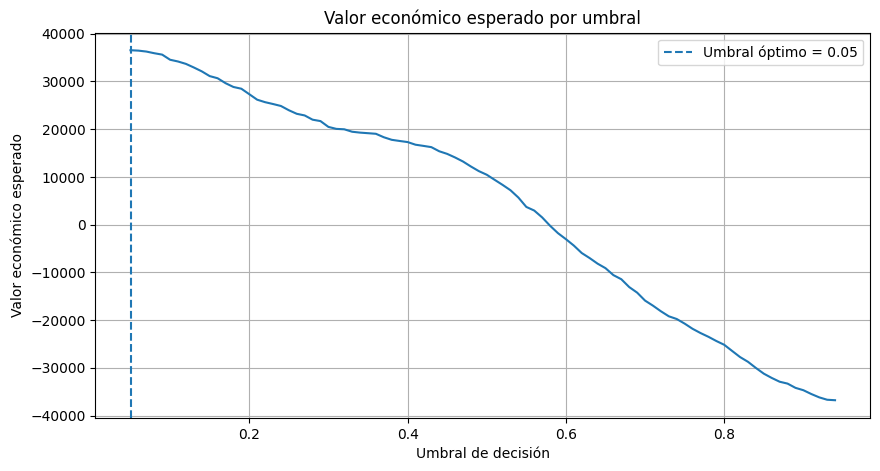

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["valor_total"])
plt.axvline(
    best_threshold_row["threshold"],
    linestyle="--",
    label=f"Umbral óptimo = {best_threshold_row['threshold']:.2f}"
)
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor económico esperado")
plt.title("Valor económico esperado por umbral")
plt.legend()
plt.grid(True)
plt.show()

## 3. Gain Curve

La curva de ganancia muestra qué porcentaje de clientes positivos puede capturarse al contactar un porcentaje específico de la población ordenada por probabilidad de conversión.

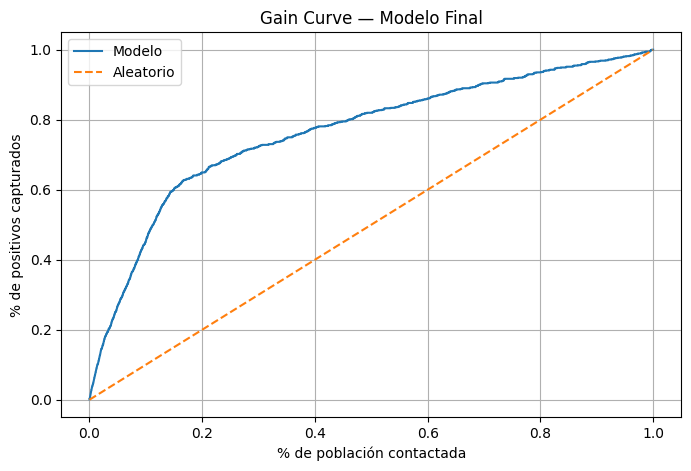

,population_pct,gain
0,0.000121,0.001079
1,0.000243,0.001079
2,0.000364,0.002157
3,0.000486,0.003236
4,0.000607,0.004315


In [36]:
gain_df = gain_curve_data(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(gain_df["population_pct"], gain_df["gain"], label="Modelo")
plt.plot([0, 1], [0, 1], "--", label="Aleatorio")
plt.xlabel("% de población contactada")
plt.ylabel("% de positivos capturados")
plt.title("Gain Curve — Modelo Final")
plt.legend()
plt.grid(True)
plt.show()

gain_df.head()

## 4. Lift Curve

La curva lift indica cuántas veces mejor es el modelo frente a una selección aleatoria.

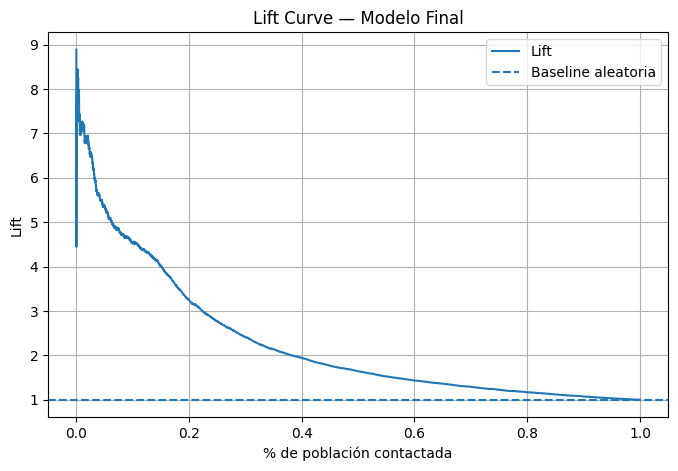

,population_pct,gain,lift
0,0.000121,0.001079,8.882416
1,0.000243,0.001079,4.441208
2,0.000364,0.002157,5.921611
3,0.000486,0.003236,6.661812
4,0.000607,0.004315,7.105933


In [37]:
lift_df = lift_curve_data(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(lift_df["population_pct"], lift_df["lift"], label="Lift")
plt.axhline(1, linestyle="--", label="Baseline aleatoria")
plt.xlabel("% de población contactada")
plt.ylabel("Lift")
plt.title("Lift Curve — Modelo Final")
plt.legend()
plt.grid(True)
plt.show()

lift_df.head()

## 5. Impacto económico estimado

Se estima el impacto mensual y anual usando el valor económico por cliente obtenido en el umbral óptimo.

Este cálculo es referencial y debe validarse con el sponsor del proyecto.

In [38]:
clientes_mes = 100000
meses = 12

impacto = estimate_annual_impact(
    valor_por_cliente=best_threshold_row["valor_por_cliente"],
    clientes_mes=clientes_mes,
    meses=meses
)

impacto

{'valor_por_cliente': np.float64(4.4389118290017),
 'clientes_mes': 100000,
 'meses': 12,
 'impacto_mensual_estimado': np.float64(443891.18290017004),
 'impacto_anual_estimado': np.float64(5326694.19480204)}

## 6. Escenarios de sensibilidad

Debido a que los valores económicos usados en la matriz costo–beneficio son supuestos de negocio, se evalúan tres escenarios: conservador, base y optimista.

Esto permite analizar si la recomendación de pasar al Sprint 6 se mantiene aun cuando cambian los costos de llamada, el beneficio neto por cliente captado y el costo de oportunidad de no contactar a un cliente interesado.

In [39]:
scenarios = {
    "Conservador": {
        "benefit_tp": 40,
        "cost_fp": -2.0,
        "cost_fn": -25,
        "benefit_tn": 0
    },
    "Base": {
        "benefit_tp": 60,
        "cost_fp": -2.5,
        "cost_fn": -40,
        "benefit_tn": 0
    },
    "Optimista": {
        "benefit_tp": 90,
        "cost_fp": -3.5,
        "cost_fn": -60,
        "benefit_tn": 0
    }
}

sensitivity_results = []

for scenario_name, params in scenarios.items():
    df_scenario, best_scenario = find_optimal_threshold(
        y_true=y_test,
        y_proba=y_proba,
        benefit_tp=params["benefit_tp"],
        cost_fp=params["cost_fp"],
        cost_fn=params["cost_fn"],
        benefit_tn=params["benefit_tn"]
    )
    
    impacto_scenario = estimate_annual_impact(
        valor_por_cliente=best_scenario["valor_por_cliente"],
        clientes_mes=clientes_mes,
        meses=meses
    )
    
    sensitivity_results.append({
        "escenario": scenario_name,
        "benefit_tp_soles": params["benefit_tp"],
        "cost_fp_soles": params["cost_fp"],
        "cost_fn_soles": params["cost_fn"],
        "umbral_optimo": best_scenario["threshold"],
        "valor_total_test": best_scenario["valor_total"],
        "valor_por_cliente": best_scenario["valor_por_cliente"],
        "precision": best_scenario["precision"],
        "recall": best_scenario["recall"],
        "f1": best_scenario["f1"],
        "impacto_mensual_estimado_soles": impacto_scenario["impacto_mensual_estimado"],
        "impacto_anual_estimado_soles": impacto_scenario["impacto_anual_estimado"]
    })

df_sensitivity = pd.DataFrame(sensitivity_results)

df_sensitivity

,escenario,benefit_tp_soles,cost_fp_soles,cost_fn_soles,umbral_optimo,valor_total_test,valor_por_cliente,precision,recall,f1,impacto_mensual_estimado_soles,impacto_anual_estimado_soles
0,Conservador,40,-2.0,-25,0.06,22086.0,2.682293,0.117731,0.976268,0.210123,268229.293175,3.218752e+06
1,Base,60,-2.5,-40,0.05,36550.0,4.438912,0.114861,0.983819,0.205707,443891.182900,5.326694e+06
2,Optimista,90,-3.5,-60,0.05,56582.0,6.871751,0.114861,0.983819,0.205707,687175.127520,8.246102e+06


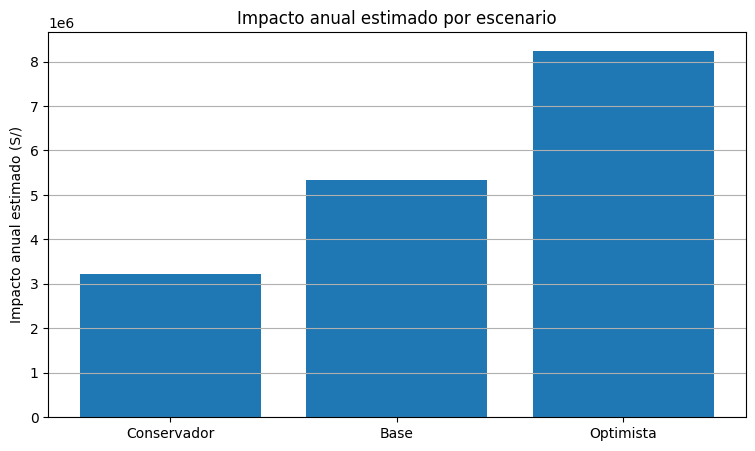

In [40]:
plt.figure(figsize=(9, 5))
plt.bar(
    df_sensitivity["escenario"],
    df_sensitivity["impacto_anual_estimado_soles"]
)

plt.ylabel("Impacto anual estimado (S/)")
plt.title("Impacto anual estimado por escenario")
plt.grid(axis="y")
plt.show()

In [41]:
df_sensitivity.to_csv(REPORTS_DIR / "business_value_sensitivity.csv", index=False)

### 6.1 Interpretación de escenarios

El análisis de sensibilidad permite validar si la recomendación de negocio se mantiene bajo distintos supuestos económicos.

- En el escenario conservador, se considera un beneficio menor por cliente captado y un costo de oportunidad más bajo.
- En el escenario base, se usan supuestos razonables para una campaña bancaria local.
- En el escenario optimista, se considera mayor valor comercial por cliente captado, pero también mayor costo por contacto improductivo.

Si el impacto económico estimado se mantiene positivo en los tres escenarios, existe mayor evidencia para recomendar el pase al Sprint 6 como MVP controlado.

### Resumen Final

In [42]:
business_summary = pd.DataFrame([{
    "modelo": "final_model.pkl",
    "umbral_optimo": best_threshold_row["threshold"],
    "valor_total_test": best_threshold_row["valor_total"],
    "valor_por_cliente": best_threshold_row["valor_por_cliente"],
    "clientes_mes": clientes_mes,
    "impacto_mensual_estimado": impacto["impacto_mensual_estimado"],
    "impacto_anual_estimado": impacto["impacto_anual_estimado"],
    "precision_umbral_optimo": best_threshold_row["precision"],
    "recall_umbral_optimo": best_threshold_row["recall"],
    "f1_umbral_optimo": best_threshold_row["f1"],
    "roc_auc": roc_auc_score(y_test, y_proba),
    "benefit_tp": benefit_tp,
    "cost_fp": cost_fp,
    "cost_fn": cost_fn,
    "benefit_tn": benefit_tn
}])

business_summary

,modelo,umbral_optimo,valor_total_test,valor_por_cliente,clientes_mes,impacto_mensual_estimado,impacto_anual_estimado,precision_umbral_optimo,recall_umbral_optimo,f1_umbral_optimo,roc_auc,benefit_tp,cost_fp,cost_fn,benefit_tn
0,final_model.pkl,0.05,36550.0,4.438912,100000,443891.1829,5.326694e+06,0.114861,0.983819,0.205707,0.798292,60,-2.5,-40,0


### Guardar Resultados

In [43]:
df_thresholds.to_csv(REPORTS_DIR / "threshold_business_value.csv", index=False)
gain_df.to_csv(REPORTS_DIR / "gain_curve.csv", index=False)
lift_df.to_csv(REPORTS_DIR / "lift_curve.csv", index=False)
business_summary.to_csv(REPORTS_DIR / "business_value_summary.csv", index=False)
df_sensitivity.to_csv(REPORTS_DIR / "business_value_sensitivity.csv", index=False)

print("Archivos guardados en reports/:")
print("- threshold_business_value.csv")
print("- gain_curve.csv")
print("- lift_curve.csv")
print("- business_value_summary.csv")
print("- business_value_sensitivity.csv")

Archivos guardados en reports/:
- threshold_business_value.csv
- gain_curve.csv
- lift_curve.csv
- business_value_summary.csv
- business_value_sensitivity.csv


## 7. Recomendación de negocio y decisión para Sprint 6

A partir del análisis de valor de negocio realizado sobre el modelo final `final_model.pkl`, se concluye que el modelo es **factible para avanzar al Sprint 6**, siempre que el despliegue se realice inicialmente como un **MVP controlado** y no como una automatización total de campañas.

### 7.1 Resultado con umbral estándar 0.50

Con el umbral tradicional de 0.50, el modelo obtiene los siguientes resultados sobre el conjunto de prueba:

| Indicador | Valor |
|---|---:|
| True Negatives (TN) | 6804 |
| False Positives (FP) | 53 |
| False Negatives (FN) | 439 |
| True Positives (TP) | 488 |
| Valor económico total | 14625.5 |
| Valor por cliente | 1.27 |
| Precision | 0.4924 |
| Recall | 0.5264 |
| F1-score | 0.5089 |

Este escenario muestra que el modelo ya genera valor positivo con el umbral base. Sin embargo, desde una perspectiva de negocio, el objetivo no es maximizar únicamente F1-score o accuracy, sino maximizar el valor económico esperado de la campaña.

### 7.2 Resultado con umbral óptimo de negocio

Al evaluar múltiples umbrales, se identificó que el mayor valor económico se obtiene con un umbral aproximado de:

**Umbral óptimo = 0.05**

Con este umbral, el modelo obtiene:

| Indicador | Valor |
|---|---:|
| Valor económico total máximo | 36550.0 |
| Valor por cliente | 4.44 |
| Precision | 0.1149 |
| Recall | 0.9838 |
| F1-score | 0.2057 |

Aunque la precisión disminuye, el recall aumenta de manera importante. Esto significa que el modelo captura una mayor proporción de clientes interesados, lo cual es coherente con el objetivo del negocio: evitar dejar pasar clientes con alta probabilidad de conversión.

En telemarketing bancario, este comportamiento es razonable cuando el costo de una llamada adicional es menor que el costo de oportunidad de no contactar a un cliente que sí podía suscribirse.

### 7.3 Interpretación de Gain Curve

La Gain Curve muestra que el modelo supera claramente a una selección aleatoria. Esto significa que, si el banco ordena a los clientes por probabilidad de suscripción y contacta primero a los de mayor score, puede capturar una proporción mayor de clientes interesados con menos llamadas.

Este resultado respalda el uso del modelo como herramienta de priorización comercial, especialmente en campañas donde el equipo de ventas tiene capacidad limitada y no puede contactar a toda la base de clientes.

### 7.4 Interpretación de Lift Curve

La Lift Curve muestra que, en los primeros segmentos de clientes priorizados, el modelo puede alcanzar un lift superior a la baseline aleatoria. En los primeros tramos, el lift observado es considerablemente mayor que 1, lo que indica que el modelo identifica grupos de clientes mucho más propensos a suscribirse que una selección al azar.

Esto es relevante para negocio porque permite construir campañas más eficientes: contactar primero al segmento con mayor propensión y reducir esfuerzos sobre clientes con baja probabilidad de conversión.

### 7.5 Impacto económico estimado

Usando el valor económico por cliente obtenido en el umbral óptimo y asumiendo una operación de 100,000 clientes evaluados por mes, se obtiene:

| Indicador | Valor (S/.) |
|---|---:|
| Valor por cliente | 4.44 |
| Clientes evaluados por mes | 100,000 |
| Impacto mensual estimado | 443,891.18 |
| Impacto anual estimado | 5,326,694.19 |

Estos valores son referenciales y dependen de los supuestos definidos para beneficio por True Positive, costo por False Positive y costo por False Negative. Por ello, deben ser validados con el sponsor del proyecto antes de una implementación productiva.

### 7.6 Recomendación final

Se recomienda avanzar al **Sprint 6 — Deployment MVP**, porque el modelo cumple tres condiciones importantes:

1. **Genera valor económico positivo** tanto con el umbral estándar 0.50 como con el umbral óptimo de negocio.
2. **Mejora la priorización frente a una estrategia aleatoria**, como se observa en las curvas Gain y Lift.
3. **Permite convertir métricas técnicas en decisiones comerciales**, definiendo un umbral operativo alineado con el costo-beneficio de la campaña.

Sin embargo, el despliegue debe realizarse como un MVP controlado, bajo las siguientes condiciones:

- Usar inicialmente el umbral óptimo de 0.05 como referencia de negocio.
- Validar los supuestos económicos con el sponsor del proyecto.
- Ejecutar una campaña piloto con grupo de control.
- Comparar la conversión real del modelo contra una estrategia tradicional o aleatoria.
- Monitorear precision, recall, tasa de contacto, tasa de conversión y valor económico real.
- Revisar periódicamente el umbral si cambian los costos de campaña o la estrategia comercial.

## Resumen ejecutivo para stakeholders

El modelo final permite priorizar clientes con mayor probabilidad de suscripción a depósitos a plazo. Con el umbral estándar de 0.50, el modelo genera un valor económico positivo de  14,625.5 en el conjunto de prueba. Al optimizar el umbral desde la perspectiva de negocio, el mejor punto se encuentra en 0.05, elevando el valor económico estimado a 36,550 y aumentando el recall a 98.38%.

Esto significa que el modelo es útil para campañas donde el objetivo principal es capturar la mayor cantidad posible de clientes interesados, aun aceptando un mayor número de llamadas a clientes que finalmente no convertirán.

La recomendación es avanzar al Sprint 6 con un MVP controlado, validando los supuestos económicos con el sponsor y midiendo el impacto real contra un grupo de control.